In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Data source import complete.


In [2]:
from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import recall_score
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
data_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray'

In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


# ===== Training transforms (WITH augmentation) =====
# train_transform = transforms.Compose([
#     transforms.Grayscale(num_output_channels=1),
#     transforms.Resize((224, 224)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(degrees=10),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5], std=[0.5])
# ])

# # ===== Validation / Test transforms (NO augmentation) =====
# val_test_transform = transforms.Compose([
#     transforms.Grayscale(num_output_channels=1),
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5], std=[0.5])
# ])

In [5]:
train_data = ImageFolder(
    root = data_dir + "/train",
    transform = transform
)

val_data = ImageFolder(
    root = data_dir + "/val",
    transform = transform
)

test_data = ImageFolder(
    root = data_dir + "/test",
    transform = transform
)

In [6]:
# Data Loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

Image shape: torch.Size([1, 224, 224])
Label: 0


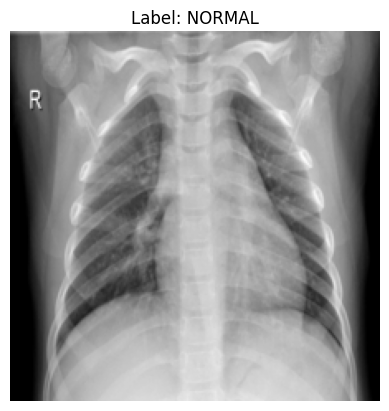

In [7]:
image, label = train_data[5]
print("Image shape:", image.shape)
print("Label:", label)

# Remove channel dimension and convert to numpy
img = image.squeeze(0).numpy()

# Undo normalization (mean=0.5, std=0.5)
# img = img * 0.5 + 0.5

plt.imshow(img, cmap="gray")
plt.title("Label: " + train_data.classes[label])
plt.axis("off")
plt.show()

In [8]:
import torch.nn as nn
import torch

class Pneumonia_NeuralNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.conv1 = nn.Conv2d(1, 16, kernel_size = 3, padding = 1)
      self.norm1 = nn.BatchNorm2d(16)

      self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, padding = 1)
      self.norm2 = nn.BatchNorm2d(32)

      self.conv3 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
      self.norm3 = nn.BatchNorm2d(64)

      self.conv4 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)
      self.norm4 = nn.BatchNorm2d(128)

      self.fc1 = nn.Linear(128 * 14 * 14, 128)
      self.fc2 = nn.Linear(128, 1) # output layer

      self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
      self.dropout = nn.Dropout(0.5)



    def forward(self, x):
      x = self.pool(torch.relu(self.norm1(self.conv1(x)))) # 1st << convolution -> batch norm -> activation -> pooling >> block
      x = self.pool(torch.relu(self.norm2(self.conv2(x)))) # 2nd << convolution -> batch norm -> activation -> pooling >> block
      x = self.pool(torch.relu(self.norm3(self.conv3(x)))) # 3rd << convolution -> batch norm -> activation -> pooling >> block
      x = self.pool(torch.relu(self.norm4(self.conv4(x)))) # 4th << convolution -> batch norm -> activation -> pooling >> block

      # x = x.view(x.size(0), -1) # flattening
      x = torch.flatten(x, 1) # flattening

      # x = torch.relu(self.fc1(x)) # fully connected layer
      x = self.dropout(torch.relu(self.fc1(x)))

      x = self.fc2(x) # output layer - uses sigmoid activation function, not mentioned here as we're using BCEWithLogitsLoss in training loop which auto applies sigmoid

      return x






In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = Pneumonia_NeuralNet().to(device)

print(model)

dummy_input = torch.randn(1, 1, 224, 224).to(device)
output = model(dummy_input)

print("Output shape:", output.shape)

Using device: cuda
Pneumonia_NeuralNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (norm4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=25088, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
)
Output shape: torch.Size([1, 1])


In [10]:
# import torch.optim as optim
# from tqdm import tqdm # for progress bars

# lossFn = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(model.parameters(), lr = 0.001)

# epochs = 11
# train_loss = []
# val_loss = []
# train_accuracy = []
# val_accuracy = []

# train_recall = []
# val_recall = []



# # ctr = 0


# # the training loop
# for epoch in range(epochs):
#   model.train()
#   curr_training_loss = 0
#   correct_train = 0
#   total_train = 0

#   # ===== T R A I N I N G =====
#   all_labels_train = []
#   all_preds_train = []

#   for X, y in tqdm(train_loader, desc = f'Epoch {epoch + 1} - Training: '): # X is images, y is labels
#     # if ctr < 5:
#     #   ctr += 1
#     #   print(X.size(0))


#     X = X.to(device)
#     y = y.float().unsqueeze(1).to(device) # BCE expects this dimension: (batch_size, 1)

#     optimizer.zero_grad() # clear gradient from previous epochs

#     yhat = model(X) # prediction

#     loss = lossFn(yhat, y) # blame assignment

#     loss.backward() # backprop / computes gradients

#     optimizer.step() # this is what actually makes the changes in weight determined by the backpropagation

#     curr_training_loss += loss.item() * X.size(0)

#     # ---- Training accuracy tracking ----
#     probs = torch.sigmoid(yhat)           # convert logits to probabilities
#     preds = (probs > 0.5).float()         # threshold at 0.5
#     correct_train += (preds == y).sum().item()
#     total_train += y.size(0)

#     # == recall ==
#     all_labels_train.extend(y.cpu().numpy())
#     all_preds_train.extend(preds.cpu().numpy())

#   epoch_train_loss = curr_training_loss / len(train_loader.dataset)
#   train_loss.append(epoch_train_loss)
#   epoch_train_acc = correct_train / total_train
#   train_accuracy.append(epoch_train_acc)

#   # == recall ==
#   epoch_train_recall = recall_score(all_labels_train, all_preds_train)
#   train_recall.append(epoch_train_recall)
#   del all_labels_train, all_preds_train

#   # ===== V A L I D A T I O N =====

#   model.eval()
#   curr_val_loss = 0
#   correct_val = 0
#   total_val = 0

#   all_labels_val = []
#   all_preds_val = []

#   with torch.no_grad():
#     for X_val, y_val in tqdm(val_loader, desc = f'Epoch {epoch + 1} - Validating: '):
#       X_val = X_val.to(device)
#       y_val = y_val.float().unsqueeze(1).to(device)

#       yhat_val = model(X_val)

#       loss_val = lossFn(yhat_val, y_val)

#       curr_val_loss += loss_val.item() * X_val.size(0)

#       # ---- Validation accuracy tracking ----
#       probs_val = torch.sigmoid(yhat_val)
#       preds_val = (probs_val > 0.5).float()
#       correct_val += (preds_val == y_val).sum().item()
#       total_val += y_val.size(0)

#       # == recall ==

#       all_labels_val.extend(y_val.cpu().numpy())
#       all_preds_val.extend(preds_val.cpu().numpy())

#     epoch_val_recall = recall_score(all_labels_val, all_preds_val)
#     val_recall.append(epoch_val_recall)
#     del all_labels_val, all_preds_val

#   epoch_val_loss = curr_val_loss / len(val_loader.dataset)
#   val_loss.append(epoch_val_loss)
#   epoch_val_acc = correct_val / total_val
#   val_accuracy.append(epoch_val_acc)

#   print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | Val Acc: {epoch_val_acc*100:.2f}% | Train Recall: {epoch_train_recall:.4f} | Val Recall: {epoch_val_recall:.4f}")



In [35]:
def train_Fn(model, train_loader, lossFn, optimizer, device, epoch):
  model.train()
  curr_training_loss = 0
  correct_train = 0
  total_train = 0

  # ===== T R A I N I N G =====
  all_labels_train = []
  all_preds_train = []

  for X, y in tqdm(train_loader, desc = f'Epoch {epoch + 1} - Training: '): # X is images, y is labels
    # if ctr < 5:
    #   ctr += 1
    #   print(X.size(0))

    X = X.to(device)
    y = y.float().unsqueeze(1).to(device) # BCE expects this dimension: (batch_size, 1)

    optimizer.zero_grad() # clear gradient from previous epochs

    yhat = model(X) # prediction

    loss = lossFn(yhat, y) # blame assignment

    loss.backward() # backprop / computes gradients

    optimizer.step() # this is what actually makes the changes in weight determined by the backpropagation

    curr_training_loss += loss.item() * X.size(0)

    # ---- Training accuracy tracking ----
    probs = torch.sigmoid(yhat)           # convert logits to probabilities
    preds = (probs > 0.1).float()         # threshold at 0.5
    correct_train += (preds == y).sum().item()
    total_train += y.size(0)

    # == recall ==
    all_labels_train.extend(y.cpu().numpy())
    all_preds_train.extend(preds.cpu().numpy())

  epoch_train_loss = curr_training_loss / len(train_loader.dataset)
  epoch_train_acc = correct_train / total_train
  epoch_train_recall = recall_score(all_labels_train, all_preds_train)

  del all_labels_train, all_preds_train

  return epoch_train_loss, epoch_train_acc, epoch_train_recall


In [36]:
# from sklearn.metrics import roc_auc_score
# def validate_Fn(model, val_loader, lossFn, device, epoch):
#   model.eval()
#   curr_val_loss = 0
#   correct_val = 0
#   total_val = 0

#   all_labels_val = []
#   all_preds_val = []

#   # roc-auc bit
#   all_probs_val = []
#   all_labels_auc = []

#   with torch.no_grad():
#     for X_val, y_val in tqdm(val_loader, desc = f'Epoch {epoch + 1} - Validating: '):
#       X_val = X_val.to(device)
#       y_val = y_val.float().unsqueeze(1).to(device)

#       yhat_val = model(X_val)

#       loss_val = lossFn(yhat_val, y_val)

#       curr_val_loss += loss_val.item() * X_val.size(0)

#       # ---- Validation accuracy tracking ----
#       probs_val = torch.sigmoid(yhat_val)
#       preds_val = (probs_val > 0.5).float()
#       correct_val += (preds_val == y_val).sum().item()
#       total_val += y_val.size(0)

#       # == recall ==
#       all_labels_val.extend(y_val.cpu().numpy())
#       all_preds_val.extend(preds_val.cpu().numpy())

#       # == roc-auc bit ==
#       all_probs_val.extend(probs_val.cpu().numpy())
#       all_labels_auc.extend(y_val.cpu().numpy())

#   epoch_val_loss = curr_val_loss / len(val_loader.dataset)
#   epoch_val_acc = correct_val / total_val
#   epoch_val_recall = recall_score(all_labels_val, all_preds_val)

#   del all_labels_val, all_preds_val

#   return epoch_val_loss, epoch_val_acc, epoch_val_recall




from sklearn.metrics import roc_auc_score

def validate_Fn(model, val_loader, lossFn, device, epoch):
  model.eval()
  curr_val_loss = 0
  correct_val = 0
  total_val = 0

  all_labels_val = []
  all_preds_val = []

  # roc-auc bit
  all_probs_val = []
  all_labels_auc = []

  with torch.no_grad():
    for X_val, y_val in tqdm(val_loader, desc = f'Epoch {epoch + 1} - Validating: '):
      X_val = X_val.to(device)
      y_val = y_val.float().unsqueeze(1).to(device)

      yhat_val = model(X_val)

      loss_val = lossFn(yhat_val, y_val)

      curr_val_loss += loss_val.item() * X_val.size(0)

      # ---- Validation accuracy tracking ----
      probs_val = torch.sigmoid(yhat_val)
      preds_val = (probs_val > 0.1).float()
      correct_val += (preds_val == y_val).sum().item()
      total_val += y_val.size(0)

      # == recall ==
      all_labels_val.extend(y_val.cpu().numpy())
      all_preds_val.extend(preds_val.cpu().numpy())

      # == roc-auc bit ==
      all_probs_val.extend(probs_val.cpu().numpy())
      all_labels_auc.extend(y_val.cpu().numpy())

  epoch_val_loss = curr_val_loss / len(val_loader.dataset)
  epoch_val_acc = correct_val / total_val
  epoch_val_recall = recall_score(all_labels_val, all_preds_val)
  epoch_val_auc = roc_auc_score(all_labels_auc, all_probs_val)

  del all_labels_val, all_preds_val, all_probs_val, all_labels_auc

  return epoch_val_loss, epoch_val_acc, epoch_val_recall, epoch_val_auc


In [37]:
print(sum(p.numel() for p in model.parameters())) # understanding model capacity

3309153


In [38]:
epochs = 10
train_loss = []
val_loss = []
train_accuracy = []
val_accuracy = []
train_recall = []
val_recall = []

lossFn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0003)

for epoch in range(epochs):
  # === T R A I N I N G ===
  epoch_train_loss, epoch_train_acc, epoch_train_recall = train_Fn(
      model, train_loader, lossFn, optimizer, device, epoch
  )

  # === V A L I D A T I O N ===
  epoch_val_loss, epoch_val_acc, epoch_val_recall, epoch_val_auc = validate_Fn(
      model, val_loader, lossFn, device, epoch
  )

  train_loss.append(epoch_train_loss)
  val_loss.append(epoch_val_loss)
  train_accuracy.append(epoch_train_acc)
  val_accuracy.append(epoch_val_acc)
  train_recall.append(epoch_train_recall)
  val_recall.append(epoch_val_recall)

  print(
      f"\nEpoch {epoch+1}/{epochs} | "
      f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
      f"Train Acc: {epoch_train_acc*100:.2f}% | Val Acc: {epoch_val_acc*100:.2f}% | "
      f"Train Recall: {epoch_train_recall:.4f} | Val Recall: {epoch_val_recall:.4f}"
  )


Epoch 1 - Validating: 100%|██████████| 1/1 [00:00<00:00,  5.23it/s]



Epoch 1/10 | Train Loss: 0.0412 | Val Loss: 0.1216 | Train Acc: 98.18% | Val Acc: 75.00% | Train Recall: 0.9961 | Val Recall: 1.0000


Epoch 2 - Validating: 100%|██████████| 1/1 [00:00<00:00,  5.05it/s]



Epoch 2/10 | Train Loss: 0.0183 | Val Loss: 0.0054 | Train Acc: 98.77% | Val Acc: 100.00% | Train Recall: 0.9987 | Val Recall: 1.0000


Epoch 3 - Validating: 100%|██████████| 1/1 [00:00<00:00,  4.86it/s]


...


Epoch 8/10 | Train Loss: 0.0131 | Val Loss: 0.0011 | Train Acc: 99.19% | Val Acc: 100.00% | Train Recall: 0.9992 | Val Recall: 1.0000


Epoch 9 - Validating: 100%|██████████| 1/1 [00:00<00:00,  5.17it/s]



Epoch 9/10 | Train Loss: 0.0063 | Val Loss: 0.0395 | Train Acc: 99.58% | Val Acc: 87.50% | Train Recall: 0.9997 | Val Recall: 1.0000


Epoch 10 - Validating: 100%|██████████| 1/1 [00:00<00:00,  4.85it/s]


Epoch 10/10 | Train Loss: 0.0086 | Val Loss: 0.0073 | Train Acc: 99.62% | Val Acc: 100.00% | Train Recall: 1.0000 | Val Recall: 1.0000


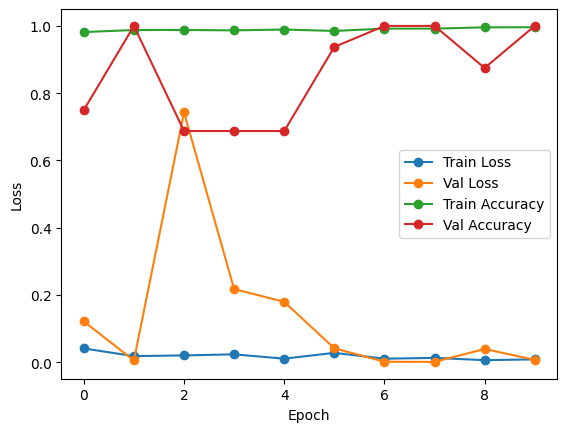

In [39]:
plt.plot(train_loss, 'o-', label="Train Loss")
plt.plot(val_loss, 'o-', label="Val Loss")
plt.plot(train_accuracy, 'o-', label="Train Accuracy")
plt.plot(val_accuracy, 'o-', label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [40]:
model.eval() # important: disables dropout & batchnorm updates

test_loss = 0.0
correct = 0
total = len(test_data)

with torch.no_grad():
  for X, y in tqdm(test_loader, desc = f'Testinggggg: '):
    X = X.to(device)
    y = y.float().unsqueeze(1).to(device)

    yhat = model(X)

    loss = lossFn(yhat, y)

    test_loss += loss.item() * X.size(0)

    probs = torch.sigmoid(yhat)
    preds = (probs > 0.5).float()

    correct += (preds == y).sum().item()

accuracy = correct / total * 100

Testinggggg: 100%|██████████| 20/20 [00:08<00:00,  2.44it/s]


In [41]:
accuracy

74.67948717948718

In [42]:
print(f"Epoch {epoch+1} | Val AUC: {epoch_val_auc:.4f}")

Epoch 10 | Val AUC: 1.0000


In [43]:
from collections import Counter

class_counts = Counter(train_data.targets)

for class_idx, count in class_counts.items():
    print(f"{train_data.classes[class_idx]}: {count}")

NORMAL: 1341
PNEUMONIA: 3875


ROC-AUC: 1.0


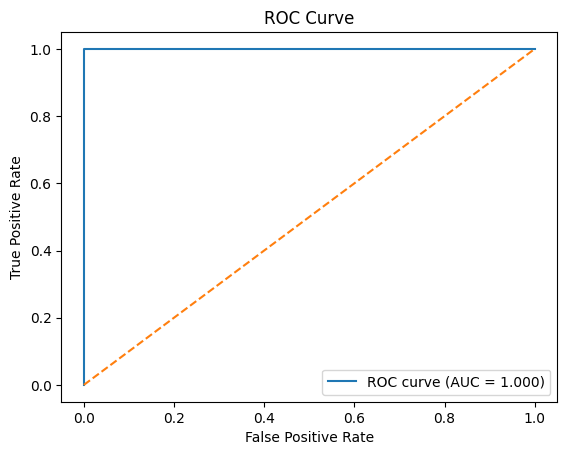

In [44]:
# plotting roc-auc
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for X, y in val_loader:   # use test_loader for final report
        X = X.to(device)
        y = y.float().unsqueeze(1).to(device)

        logits = model(X)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# computing roc-auc
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# plotting
print("ROC-AUC:", roc_auc)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [45]:
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    preds = (np.array(all_probs) > t).astype(int)

    acc = accuracy_score(all_labels, preds)
    rec = recall_score(all_labels, preds)
    f1  = f1_score(all_labels, preds)

    results.append((t, acc, rec, f1))

for t, acc, rec, f1 in results:
    print(f"Threshold={t:.2f} | Acc={acc:.3f} | Recall={rec:.3f} | F1={f1:.3f}")


Threshold=0.10 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.15 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.20 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.25 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.30 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.35 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.40 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.45 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.50 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.55 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.60 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.65 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.70 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.75 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.80 | Acc=1.000 | Recall=1.000 | F1=1.000
Threshold=0.85 | Acc=1.000 | Recall=1.000 | F1=1.000


In [34]:
best_threshold = max(results, key=lambda x: x[2])[0]  # best recall
print("Best threshold (recall-based):", best_threshold)

Best threshold (recall-based): 0.1
